In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import NL_Trumelan
from pathlib import Path

In [2]:
driver = "nSyb"
responder = "eOPN3"
time ="5s"
genotypefilename = driver + " x " + responder
control1name = "w1118 x " + driver
control2name = "w1118 x " + responder


if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"
transgenicnaming = driver + " > " + responderrename

base_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\TruMelan\\Reformatted\\"  

# output_dir = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images"  

# Analysis parameters
bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
illum_duration = 5  # illumination duration (seconds)


#exp_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\TruMelan\\Jonny\\eOPN3 PIEZO\\Piezo x eOPN3_Green_1s"

exp_path = base_path + genotypefilename
control1_path = base_path + control1name
control2_path = base_path + control2name

## IDX to csv

In [3]:
input_folder = r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data\TruMelan\Jonny\eOPN3 PIEZO\06-06-2022 m4xPiezo Green"

custom_name = "elav x ACR Green_5s"  #put to None, if same exact name as folder. output will be in the format of: date {insert custom name}_fly number
NL_Trumelan.idx_to_csv(input=input_folder, output=input_folder, custom_name=custom_name)

100%|██████████| 166644/166644 [00:00<00:00, 272385.38it/s]


## Generating total processing file

In [3]:
exp_combined_df = NL_Trumelan.process_genotype_data(exp_path, time_filter=time, max_time=300, bin_size = 0.5)

exp_combined_df


Time filter '5s' applied: 24 files found


,Speed_1,Speed_2,Speed_3,Speed_4,Speed_5,Speed_6,Speed_7,Speed_8,Speed_9,Speed_10,...,ActivityLevelLog10_15,ActivityLevelLog10_16,ActivityLevelLog10_17,ActivityLevelLog10_18,ActivityLevelLog10_19,ActivityLevelLog10_20,ActivityLevelLog10_21,ActivityLevelLog10_22,ActivityLevelLog10_23,ActivityLevelLog10_24
Time (s),,,,,,,,,,,,,,,,,,,,,
0.0,1.352121,1.398661,0.167703,0.067757,0.320756,0.000000,0.267323,0.940862,0.060898,1.057711,...,3.532525,3.513830,3.632801,3.533620,3.606037,3.517090,3.506343,3.735695,3.515052,3.586317
0.5,4.476812,2.789009,0.411173,0.036081,0.389478,0.000000,4.502399,1.772626,0.168908,0.500655,...,2.481729,2.749427,3.188647,2.259116,2.705522,1.107210,0.079181,3.504688,2.080626,2.586137
1.0,2.542729,1.839542,3.083955,0.089778,0.132884,0.000000,5.285523,0.252355,0.075327,0.430207,...,2.258158,3.118397,3.039255,2.562769,3.226961,1.978637,0.000000,3.433001,2.635081,2.490801
1.5,5.415606,1.486507,1.604758,0.088068,0.094112,0.000000,0.393719,0.071614,0.213761,0.641359,...,2.491362,2.919706,2.995811,2.390582,3.283979,0.579784,2.383097,3.244920,2.403464,2.131619
2.0,0.762247,1.552104,0.588201,0.064618,0.108086,0.000000,0.567727,0.025030,0.084376,1.654158,...,2.553883,3.160409,3.013848,2.379487,3.066773,2.707059,2.198107,2.563006,2.429752,2.026942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297.5,0.046324,2.461744,0.000000,1.274563,0.213752,0.008486,0.297220,0.256288,0.005569,0.007332,...,3.343290,2.857815,0.146128,0.000000,2.640879,0.000000,0.000000,2.926445,3.438257,0.602060
298.0,0.040871,2.204303,0.000000,3.140494,0.166780,0.010386,0.232757,0.188321,0.008534,0.012211,...,3.329317,2.615108,0.146128,0.000000,1.536558,0.146128,0.079181,3.021685,2.872739,0.000000
298.5,0.018204,1.874491,0.000000,3.627888,0.294882,0.015645,0.204557,0.252628,0.004464,0.011542,...,3.124374,0.414973,0.079181,0.000000,2.629410,0.000000,0.000000,2.791831,2.888292,0.079181


Time filter '5s' applied: 24 files found


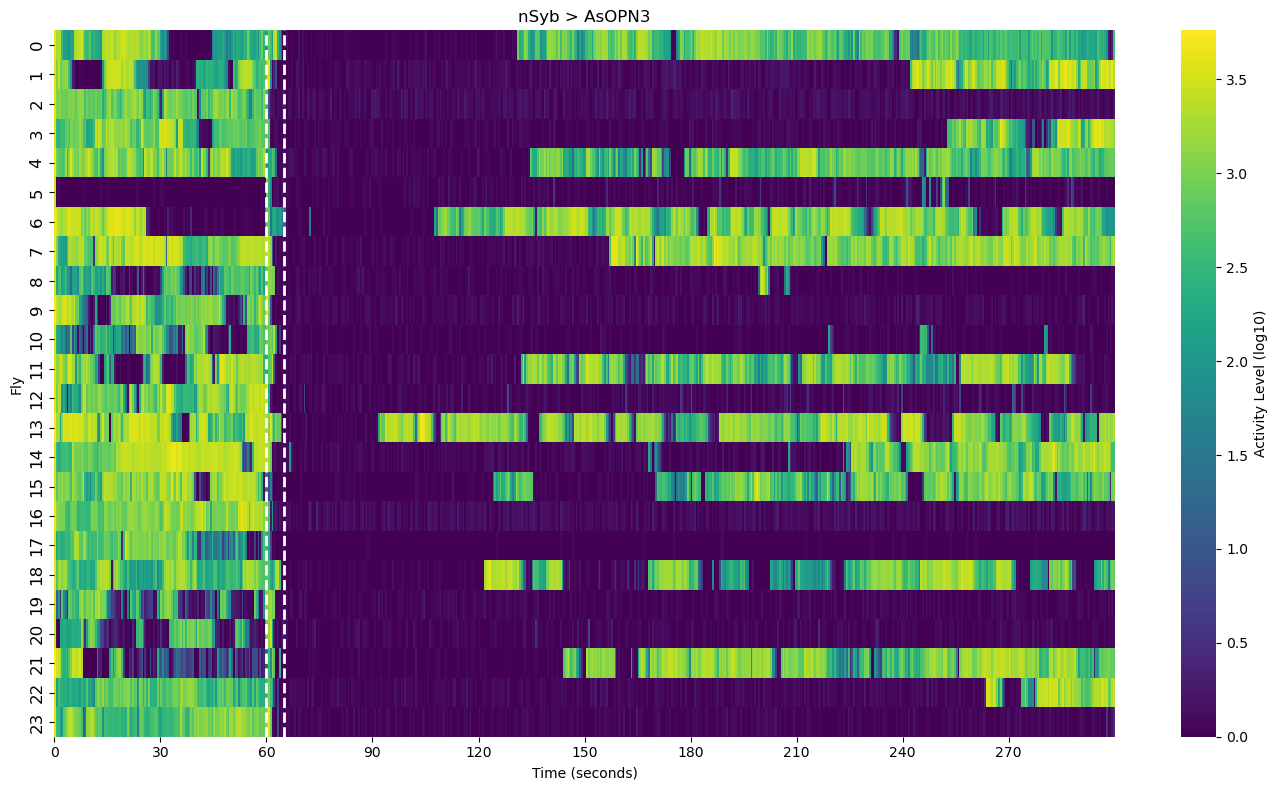

In [ ]:
activityleveldf = exp_combined_df.filter(regex="^ActivityLevel").T.reset_index(drop=True)


plt.figure(figsize=(14, 8))
ax = sns.heatmap(activityleveldf, cmap="viridis", cbar_kws={'label': 'Activity Level (log10)'}, xticklabels=12, yticklabels=True)
plt.yticks(fontsize=12)

# Add illumination lines
illum_start_idx = int(illum_start // bin_size)
illum_end_idx = int((illum_start + illum_duration) // bin_size)
plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)

tick_times = range(0, 300, 30)  # 0, 30, 60, 90, ...
tick_positions = [list(activityleveldf.columns).index(float(t)) for t in tick_times if float(t) in activityleveldf.columns]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_times, rotation = 0)

plt.xlabel("Time (seconds)")
plt.ylabel("Fly")
plt.title(transgenicnaming)
plt.tight_layout()


## Heatmap

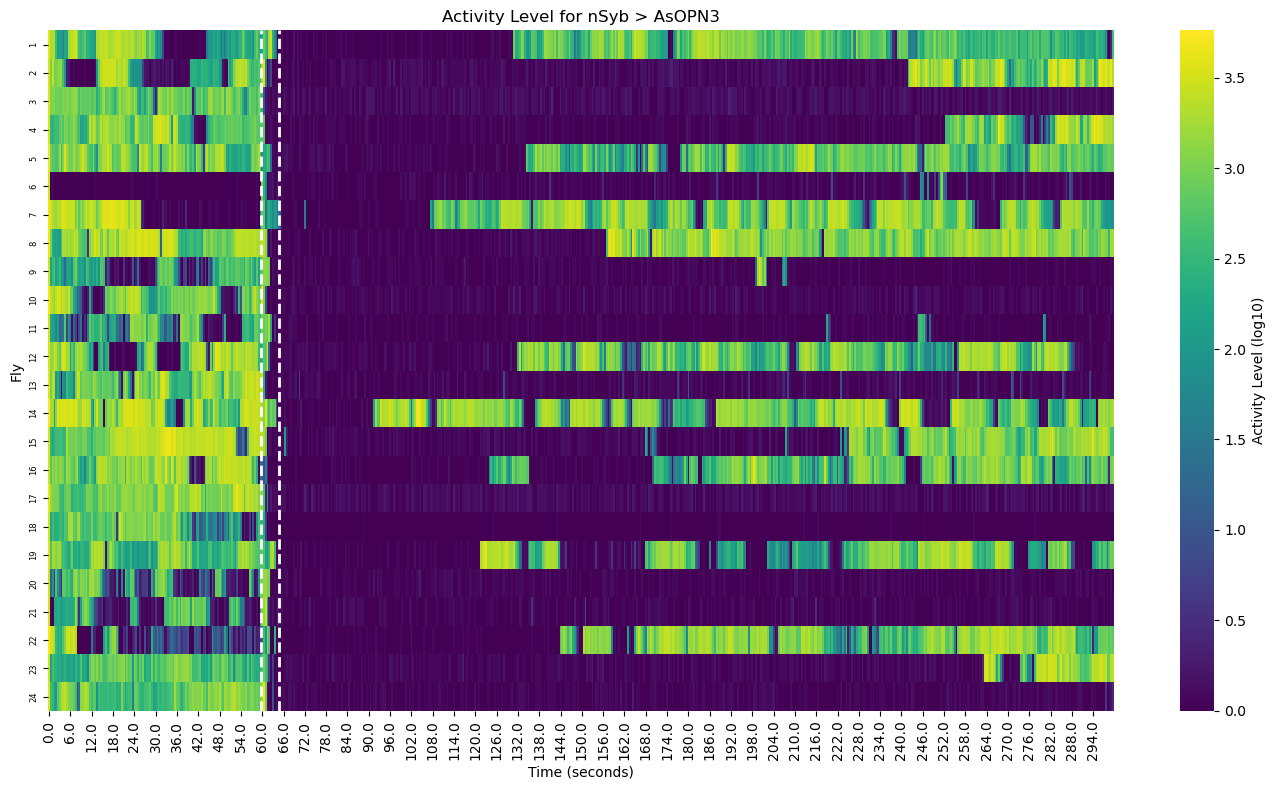

In [37]:
metrics = ["Activity Level"]
metric_labels = ["Activity Level"]

# Check if folders exist
folders_exist = {
    "experimental": os.path.exists(exp_path),
}


for metric, metric_label in zip(metrics, metric_labels):
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        activitylevel_df = load_csv_data(exp_path, metric, time_filter=time)
        if activitylevel_df is not None:
            fig = create_heatmap(
                activitylevel_df, 
                f"{metric_label} for {transgenicnaming}", max_time = 300,
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
        else:
            print(f"No data found in {exp_path}")
    else:
        print(f"Experimental folder not found: {exp_path}")

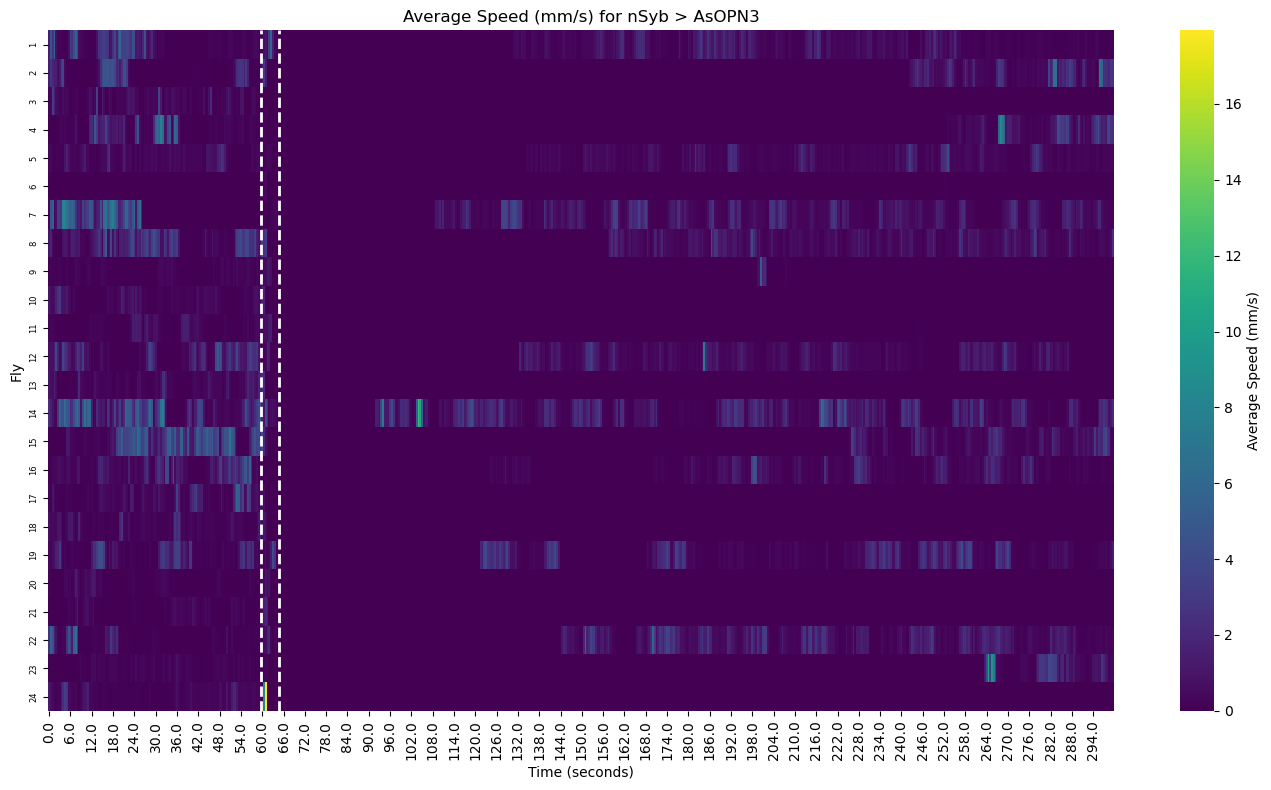

In [17]:
metrics = ["Speed_Av_mm_per_sec"]
metric_labels = ["Average Speed (mm/s)"]

# Check if folders exist
folders_exist = {
    "experimental": os.path.exists(exp_path),
}


for metric, metric_label in zip(metrics, metric_labels):
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        speeddata_df = load_csv_data(exp_path, metric, time_filter=time)
        if speeddata_df is not None:
            fig = create_heatmap(
                speeddata_df, 
                f"{metric_label} for {transgenicnaming}", max_time = 300,
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
        else:
            print(f"No data found in {exp_path}")
    else:
        print(f"Experimental folder not found: {exp_path}")

In [18]:
activitylevel_df

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000,12771.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,...,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,16038.0,15840.0,16038.0
0.101,1840.0,468.0,1663.0,261.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.201,2038.0,530.0,832.0,184.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3062.0,154.0,897.0
0.301,2665.0,437.0,829.0,414.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,113.0,616.0,67.0,0.0,3022.0,149.0,655.0
0.401,2477.0,654.0,487.0,424.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,104.0,819.0,18.0,0.0,3154.0,23.0,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3502.543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,29.0
3547.668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3576.484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,14.0


In [19]:
speeddata_df

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000,0.036490,1.267169,0.216976,0.091979,0.365093,0.0,0.172757,0.938176,0.061427,1.623608,...,0.063307,0.086122,0.604271,0.346055,0.738398,0.053087,0.0,3.621236,0.042620,0.764004
0.101,0.409675,0.670446,0.207711,0.094201,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.201,1.215556,0.918785,0.197054,0.068423,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.892941,0.109882,1.610389
0.301,2.109449,1.715860,0.154941,0.023187,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000271,0.400304,0.263635,0.0,2.051010,0.088065,1.602561
0.401,2.989438,2.421044,0.061835,0.060992,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.880574,0.314945,0.182433,0.0,2.896715,0.084498,1.374554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3502.543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.057491,0.015707,0.011176
3547.668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.005600,0.010978,0.006792
3576.484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001933,0.004890,0.018663
